In [34]:
pip install h5py rasterio numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [35]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [36]:
# Path to your file
file_path = r"E:\SEM 2\TMHRS\hyperspectral_ass\NEON_refl-surf-dir-ortho-mosaic\NEON_refl-surf-dir-ortho-mosaic\NEON.D10.STER.DP3.30006.001.2021-06.basic.20260420T112032Z.RELEASE-2026\NEON_D10_STER_DP3_666000_4482000_reflectance.h5"

# Open file
hdf5_file = h5py.File(file_path, 'r')

# Explore structure
print(list(hdf5_file.keys()))

['STER']


In [37]:
# Navigate (depends on file structure)
refl = hdf5_file['STER']['Reflectance']['Reflectance_Data']

# Convert to numpy
refl_array = np.array(refl)

print(list(hdf5_file.keys()))

['STER']


In [41]:
wavelength = hdf5_file['STER']['Reflectance']['Metadata']['Spectral_Data']['Wavelength']
wavelength = np.array(wavelength)

In [42]:
# Step 1: pick pixel correctly
pixel_spectrum = refl_array[100, 100, :]
# Step 2: check shapes
print("Wavelength:", wavelength.shape)
print("Pixel spectrum:", pixel_spectrum.shape)

Wavelength: (426,)
Pixel spectrum: (426,)


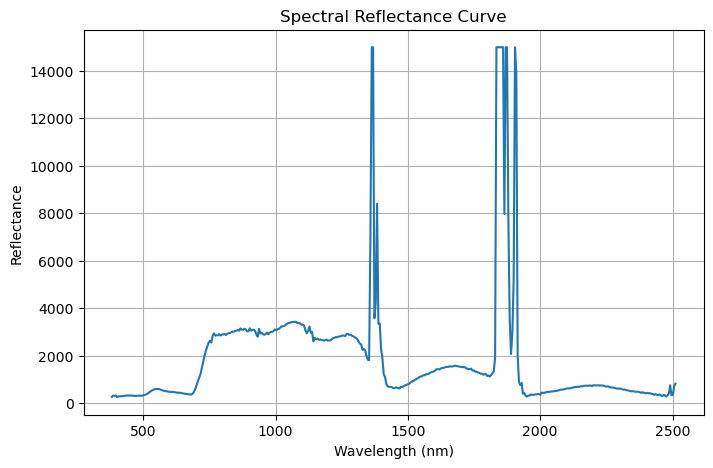

In [43]:
# Step 3: plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(wavelength, pixel_spectrum)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Spectral Reflectance Curve")
plt.grid()

plt.show()

In [52]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [53]:
# Navigate inside HDF5 structure
reflectance = f['STER']['Reflectance']['Reflectance_Data'][:]
wavelengths = f['STER']['Reflectance']['Metadata']['Spectral_Data']['Wavelength'][:]
print("Shape:", reflectance.shape)

Shape: (1000, 1000, 426)


In [54]:
# 3. Remove NoData values
reflectance = reflectance.astype(float)
reflectance[reflectance == -9999] = np.nan

In [55]:
# 4. Select RGB Bands
# Approx wavelengths for RGB
red_band = np.argmin(np.abs(wavelengths - 660))
green_band = np.argmin(np.abs(wavelengths - 550))
blue_band = np.argmin(np.abs(wavelengths - 470))
# Extract bands
R = reflectance[:, :, red_band]
G = reflectance[:, :, green_band]
B = reflectance[:, :, blue_band]

In [56]:
# 5. Normalize Bands (IMPORTANT)
def stretch(band):
    p2, p98 = np.nanpercentile(band, (2, 98))   # stretch between 2% and 98%
    band = np.clip((band - p2) / (p98 - p2), 0, 1)
    return band

R = stretch(R)
G = stretch(G)
B = stretch(B)
# Stack RGB
rgb = np.dstack((R, G, B))
gamma = 0.5   # <1 makes image brighter

rgb = np.power(rgb, gamma)

In [58]:
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

def stretch(arr):
    return arr  # simple version (or use np.clip if needed)# 6. False Color (NIR, Red, Green)
nir_band = np.argmin(np.abs(wavelengths - 800))
NIR = normalize(reflectance[:, :, nir_band])
false_color = np.dstack((NIR, R, G))
NIR = stretch(NIR)

false_color = np.dstack((NIR, R, G))
false_color = np.power(false_color, gamma)

In [59]:
# Get exact wavelengths used
red_wl = wavelengths[red_band]
green_wl = wavelengths[green_band]
blue_wl = wavelengths[blue_band]

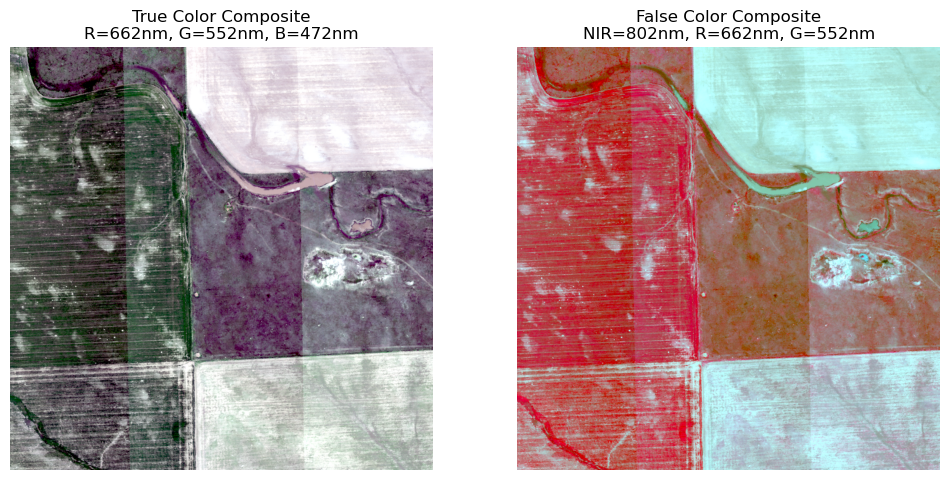

In [60]:
# 7. Plot Images
plt.figure(figsize=(12,6))

# True RGB
plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title(f"True Color Composite\nR={red_wl:.0f}nm, G={green_wl:.0f}nm, B={blue_wl:.0f}nm")
plt.axis('off')

# False Color
plt.subplot(1,2,2)
plt.imshow(false_color)
plt.title(f"False Color Composite\nNIR={wavelengths[nir_band]:.0f}nm, R={red_wl:.0f}nm, G={green_wl:.0f}nm")
plt.axis('off')

plt.show()

Shape: (1000, 1000, 426)
Bands: 662.221 552.0048 471.8475 802.4962


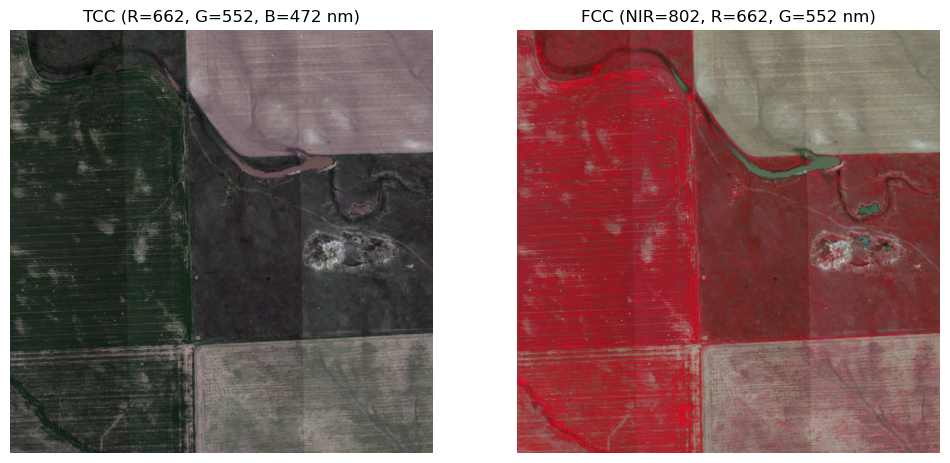

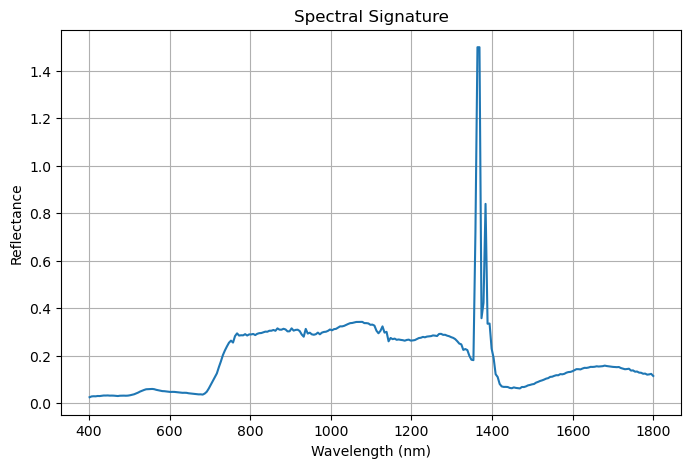

In [65]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ================================
# 2. LOAD FILE
# ================================
file_path = r"E:\SEM 2\TMHRS\hyperspectral_ass\NEON_refl-surf-dir-ortho-mosaic\NEON_refl-surf-dir-ortho-mosaic\NEON.D10.STER.DP3.30006.001.2021-06.basic.20260420T112032Z.RELEASE-2026\NEON_D10_STER_DP3_666000_4482000_reflectance.h5"

f = h5py.File(file_path, 'r')

# ================================
# 3. READ DATA
# ================================
reflectance = f['STER']['Reflectance']['Reflectance_Data'][:]
wavelengths = f['STER']['Reflectance']['Metadata']['Spectral_Data']['Wavelength'][:]

print("Shape:", reflectance.shape)

# ================================
# 4. CLEAN + SCALE DATA
# ================================
reflectance = reflectance.astype(float)

# Remove NoData
reflectance[reflectance == -9999] = np.nan

# SCALE (CRITICAL FOR NEON)
reflectance = reflectance / 10000.0

# ================================
# 5. BAND SELECTION
# ================================
def get_band(target):
    return np.argmin(np.abs(wavelengths - target))

r_band = get_band(660)
g_band = get_band(550)
b_band = get_band(470)
nir_band = get_band(800)

print("Bands:",
      wavelengths[r_band],
      wavelengths[g_band],
      wavelengths[b_band],
      wavelengths[nir_band])

# Extract bands
R = reflectance[:, :, r_band]
G = reflectance[:, :, g_band]
B = reflectance[:, :, b_band]
NIR = reflectance[:, :, nir_band]

# ================================
# 6. PROPER CONTRAST STRETCH
# ================================
def stretch(arr):
    p2, p98 = np.nanpercentile(arr, (2, 98))
    arr = (arr - p2) / (p98 - p2)
    return np.clip(arr, 0, 1)

# Better visualization enhancement
def enhance(arr):
    arr = np.nan_to_num(arr)
    arr = (arr - np.mean(arr)) / np.std(arr)
    arr = (arr - arr.min()) / (arr.max() - arr.min())
    return np.clip(arr, 0, 1)

R = enhance(R)
G = enhance(G)
B = enhance(B)
NIR = enhance(NIR)

# ================================
# 7. CREATE COMPOSITES
# ================================
TCC = np.dstack((R, G, B))
FCC = np.dstack((NIR, R, G))

# ================================
# 8. GAMMA CORRECTION
# ================================
gamma = 0.8
TCC = np.power(TCC, gamma)
FCC = np.power(FCC, gamma)

# ================================
# 9. DISPLAY OUTPUT
# ================================
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(TCC)
plt.title(f"TCC (R={wavelengths[r_band]:.0f}, G={wavelengths[g_band]:.0f}, B={wavelengths[b_band]:.0f} nm)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(FCC)
plt.title(f"FCC (NIR={wavelengths[nir_band]:.0f}, R={wavelengths[r_band]:.0f}, G={wavelengths[g_band]:.0f} nm)")
plt.axis('off')

plt.show()

# ================================
# 10. SPECTRAL SIGNATURE (OPTIONAL)
# ================================
pixel = reflectance[100, 100, :]

valid = (wavelengths > 400) & (wavelengths < 1800)

plt.figure(figsize=(8,5))
plt.plot(wavelengths[valid], pixel[valid])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Spectral Signature")
plt.grid()
plt.show()